# Monte Carlo Simulation of Sensor Noise

## Import Libraries

In [67]:
import pandas as pd
import numpy as np
import sys

import matplotlib.pyplot as plt

## Load Dataset

In [68]:
df = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/04_Phase_2_Time_Series/Layer B_Signal Behavior/dataset/ndvi_timeseries.csv")

## Routine work

In [69]:
# Convert date column
sys.path.append('/content/drive/MyDrive/Agri_RS_AI_Project')
from src.time_processing import prepare_time_index

df = prepare_time_index(df)

# Droping extra column
df = df.drop(
    columns=['system:index', '.geo'],
    errors='ignore'
    )

# Remove missing value
df.dropna(inplace=True)

# Remove duplicate
duplicates = df.index.duplicated().sum()
df = df[~df.index.duplicated(keep="first")]

## Monte Carlo Settings

In [70]:
# Number of Monte Carlo simulations
n_simulations = 100

# Standard deviation of sensor noise
noise_std = 0.02

##Generate Noisy NDVI Realizations

In [71]:
simulations = []

for i in range(n_simulations):

    noise = np.random.normal(
        loc=0, #The average value of the generated noise is 0.
        scale=noise_std,
        size=len(df)
    )

    noisy_signal = df["NDVI"].values + noise

    simulations.append(noisy_signal)

## Convert to DataFrame

In [72]:
simulation_df = pd.DataFrame(
    np.column_stack(simulations),
    index=df.index
)

simulation_df.columns = [
    f"Simulation_{i+1}"
    for i in range(n_simulations)
]

print(simulation_df.shape)
simulation_df.head()

(69, 100)


,Simulation_1,Simulation_2,Simulation_3,Simulation_4,Simulation_5,Simulation_6,Simulation_7,Simulation_8,Simulation_9,Simulation_10,...,Simulation_91,Simulation_92,Simulation_93,Simulation_94,Simulation_95,Simulation_96,Simulation_97,Simulation_98,Simulation_99,Simulation_100
date,,,,,,,,,,,,,,,,,,,,,
2023-01-09,0.559901,0.497731,0.573046,0.524580,0.519869,0.527653,0.532752,0.564701,0.508973,0.541397,...,0.485555,0.532473,0.531759,0.503035,0.549589,0.495128,0.560141,0.502636,0.564018,0.482178
2023-01-19,0.369897,0.383109,0.378847,0.388387,0.385282,0.369405,0.397813,0.384201,0.381202,0.377691,...,0.389214,0.345535,0.402823,0.367056,0.373678,0.372185,0.370190,0.372941,0.387271,0.377258
2023-01-24,0.553884,0.566064,0.561828,0.546148,0.600931,0.532193,0.560167,0.577327,0.589490,0.548650,...,0.579996,0.555518,0.565673,0.563811,0.574023,0.585082,0.562365,0.578892,0.577419,0.591459
2023-02-03,0.540641,0.547811,0.556374,0.538971,0.553696,0.503496,0.525105,0.535280,0.565818,0.540479,...,0.551617,0.532529,0.573759,0.518961,0.496155,0.542557,0.530612,0.544285,0.566618,0.543084
2023-02-13,0.461316,0.534089,0.467766,0.481009,0.485730,0.467804,0.475965,0.480486,0.498312,0.485478,...,0.501599,0.467307,0.452766,0.486590,0.459238,0.478314,0.466994,0.499878,0.451620,0.505482


## Visualize Monte Carlo Realizations

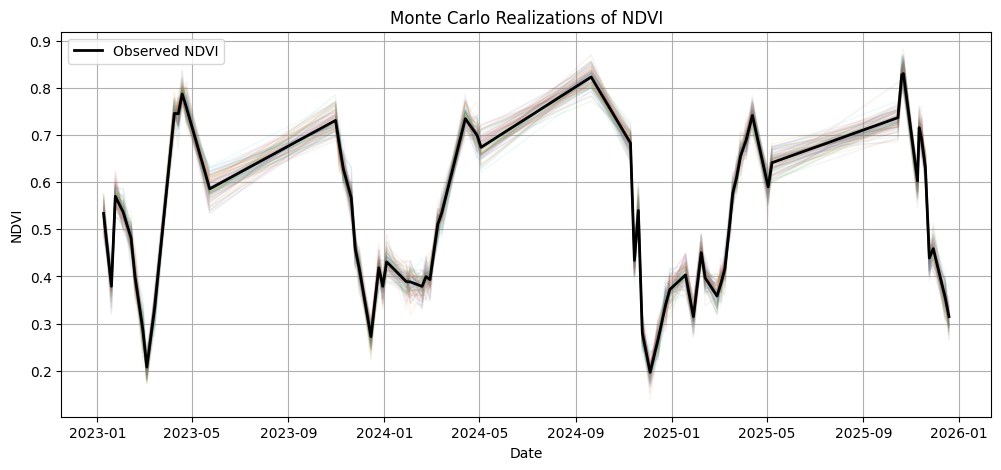

In [73]:
plt.figure(figsize=(12,5))

# Plot every realization
for col in simulation_df.columns:

    plt.plot(
        simulation_df.index,
        simulation_df[col],
        alpha=0.08,
        linewidth=1
    )

# Original signal
plt.plot(
    df.index,
    df["NDVI"],
    color="black",
    linewidth=2,
    label="Observed NDVI"
)

plt.title("Monte Carlo Realizations of NDVI")

plt.xlabel("Date")
plt.ylabel("NDVI")

plt.grid(True)

plt.legend()

plt.show()

# Smoothing Every Simulation & Feature Extraction

## Smooth Every Monte Carlo Realization

In [74]:
!pip install pybaselines
from pybaselines import Baseline

baseline = Baseline()

In [75]:
smoothed_simulations = pd.DataFrame(index=simulation_df.index)

lam = 1
p = 0.5

for col in simulation_df.columns:

    smoothed_signal, _ = baseline.asls(
        simulation_df[col].values,
        lam=lam,
        p=p
    )

    smoothed_simulations[col] = smoothed_signal

smoothed_simulations.head()

,Simulation_1,Simulation_2,Simulation_3,Simulation_4,Simulation_5,Simulation_6,Simulation_7,Simulation_8,Simulation_9,Simulation_10,...,Simulation_91,Simulation_92,Simulation_93,Simulation_94,Simulation_95,Simulation_96,Simulation_97,Simulation_98,Simulation_99,Simulation_100
date,,,,,,,,,,,,,,,,,,,,,
2023-01-09,0.514932,0.474398,0.528061,0.496326,0.493656,0.491443,0.505621,0.525002,0.485377,0.503093,...,0.469800,0.488255,0.506964,0.474013,0.512310,0.473733,0.516192,0.476814,0.526873,0.465779
2023-01-19,0.495891,0.486056,0.506689,0.489528,0.500995,0.476291,0.497515,0.507935,0.495706,0.491172,...,0.487024,0.478273,0.504204,0.476767,0.493643,0.484239,0.497013,0.485724,0.511823,0.484077
2023-01-24,0.499333,0.509381,0.507808,0.496858,0.521440,0.479245,0.502973,0.510718,0.517833,0.498404,...,0.512126,0.490400,0.513843,0.494031,0.493615,0.505442,0.499809,0.507544,0.515346,0.510575
2023-02-03,0.484746,0.504565,0.489991,0.481871,0.510242,0.464966,0.485712,0.491334,0.506304,0.487199,...,0.504079,0.480378,0.497586,0.485463,0.470883,0.492015,0.483143,0.498795,0.493739,0.500062
2023-02-13,0.438894,0.460143,0.438818,0.432771,0.462397,0.424590,0.438042,0.441069,0.451491,0.445092,...,0.455790,0.436506,0.443058,0.445606,0.424309,0.438447,0.436853,0.451670,0.434336,0.447771


## Compare a Few Simulations

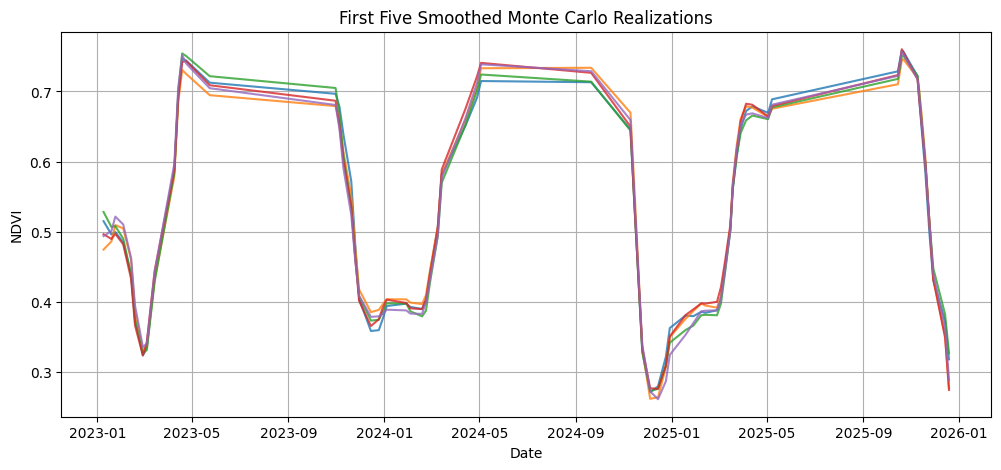

In [76]:
plt.figure(figsize=(12,5))

for col in smoothed_simulations.columns[:5]:

    plt.plot(
        smoothed_simulations.index,
        smoothed_simulations[col],
        linewidth=1.5,
        alpha=0.8
    )

plt.title("First Five Smoothed Monte Carlo Realizations")

plt.xlabel("Date")
plt.ylabel("NDVI")

plt.grid(True)

plt.show()

## Extract Vegetation Features

In [77]:
features = pd.DataFrame(index=smoothed_simulations.columns)

# Peak NDVI
features["Peak_NDVI"] = smoothed_simulations.max(axis=0)

# Peak Date
features["Peak_Date"] = smoothed_simulations.idxmax(axis=0)

# Seasonal Mean
features["Seasonal_Mean"] = smoothed_simulations.mean(axis=0)

# Area Under Curve (AUC)
features["AUC"] = smoothed_simulations.apply(
    lambda x: np.trapz(x),
    axis=0
)

/tmp/ipykernel_1103/1703187356.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lambda x: np.trapz(x),


## Inspect Features

In [78]:
features.head()

,Peak_NDVI,Peak_Date,Seasonal_Mean,AUC
Simulation_1,0.758177,2025-10-20,0.517652,35.301636
Simulation_2,0.745862,2025-10-22,0.518732,35.416816
Simulation_3,0.754297,2023-04-19,0.515720,35.157464
Simulation_4,0.760254,2025-10-20,0.517801,35.343060
Simulation_5,0.757048,2025-10-20,0.516192,35.226306


## Monte Carlo Summary Statistics

In [79]:
summary = pd.DataFrame({
    "Mean": features.mean(numeric_only=True),
    "Std": features.std(numeric_only=True),
    "Min": features.min(numeric_only=True),
    "Max": features.max(numeric_only=True)
})
print(summary)

                    Mean       Std        Min        Max
Peak_NDVI       0.763003  0.008449   0.744866   0.786023
Seasonal_Mean   0.517971  0.002184   0.510532   0.523112
AUC            35.337869  0.150142  34.832774  35.685834


# Statistical Analysis of Uncertainty

## Compute Empirical 95% Simulation Interval

In [80]:
summary["Lower_95"] = [
    np.percentile(features[col], 2.5)
    for col in summary.index
]

summary["Upper_95"] = [
    np.percentile(features[col], 97.5)
    for col in summary.index
]

summary

,Mean,Std,Min,Max,Lower_95,Upper_95
Peak_NDVI,0.763003,0.008449,0.744866,0.786023,0.747148,0.782133
Seasonal_Mean,0.517971,0.002184,0.510532,0.523112,0.513662,0.521799
AUC,35.337869,0.150142,34.832774,35.685834,35.045215,35.606458


## Distribution of Peak NDVI

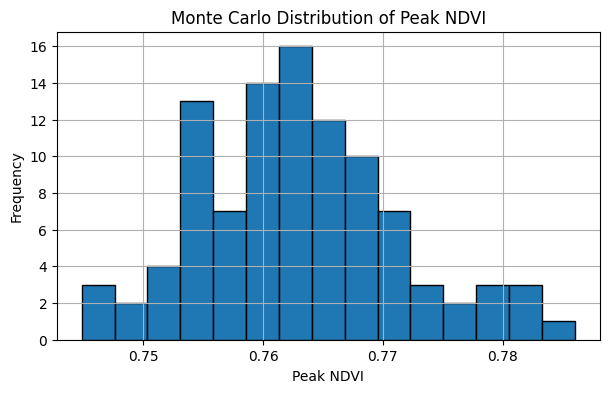

In [81]:
plt.figure(figsize=(7,4))

plt.hist(
    features["Peak_NDVI"],
    bins=15,
    edgecolor="black"
)

plt.xlabel("Peak NDVI")
plt.ylabel("Frequency")

plt.title("Monte Carlo Distribution of Peak NDVI")

plt.grid(True)

plt.show()

## Plot Mean Curve with 95% Simulation Band

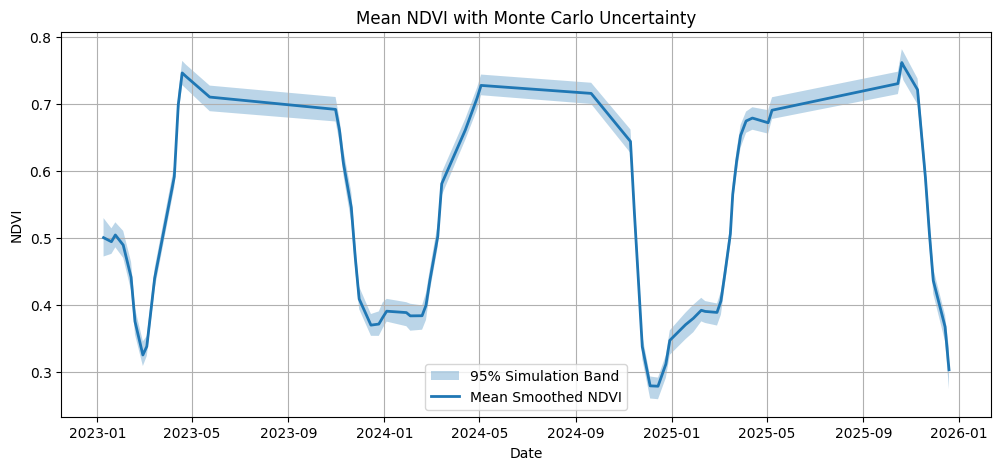

In [82]:
mean_curve = smoothed_simulations.mean(axis=1)
lower_band = smoothed_simulations.quantile(0.025, axis=1)
upper_band = smoothed_simulations.quantile(0.975, axis=1)

plt.figure(figsize=(12,5))

plt.fill_between(
    mean_curve.index,
    lower_band,
    upper_band,
    alpha=0.30,
    label="95% Simulation Band"
)

plt.plot(
    mean_curve.index,
    mean_curve,
    linewidth=2,
    label="Mean Smoothed NDVI"
)

plt.xlabel("Date")

plt.ylabel("NDVI")

plt.title("Mean NDVI with Monte Carlo Uncertainty")

plt.grid(True)

plt.legend()

plt.show()